# Module 05: Scikit-Learn for Machine Learning
## Notebook 05: Rigorous Cross-Validation and Hyperparameter Optimization

A model evaluated on a single arbitrary train/test split risks overfitting or luck. In production machine learning, models must be validated using Stratified K-Fold or Time-Series cross-validation, tuned systematically via grid or randomized search, and serialized for deployment.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement **Stratified K-Fold Cross-Validation** to prevent single-split bias.
2. Perform exhaustive search with **`GridSearchCV`**.
3. Scale to large search spaces using **`RandomizedSearchCV`**.
4. Diagnose **Underfitting vs. Overfitting** using **`learning_curve()`**.
5. Serialize production models using **`joblib`**.
6. **Advanced:** Implement temporal walk-forward validation with **`TimeSeriesSplit`** to prevent future lookahead leakage, evaluating multi-metric scores simultaneously.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve, TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

print("Scikit-Learn loaded!")

Scikit-Learn loaded!


### 1. Stratified K-Fold Cross-Validation

Standard $K$-Fold randomly splits data into $K$ chunks.
**Stratified K-Fold** guarantees that each fold contains the exact same percentage of target classes as the complete dataset:

In [2]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Stratified K-Fold with 5 splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_baseline = RandomForestClassifier(n_estimators=50, random_state=42)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]
    
    rf_baseline.fit(X_train_f, y_train_f)
    score = rf_baseline.score(X_val_f, y_val_f)
    fold_scores.append(score)
    print(f"Fold {fold} Validation Accuracy: {score*100:.2f}%")

print(f"\nMean CV Accuracy: {np.mean(fold_scores)*100:.2f}% (+/- {np.std(fold_scores)*100:.2f}%)")

Fold 1 Validation Accuracy: 96.49%
Fold 2 Validation Accuracy: 92.98%
Fold 3 Validation Accuracy: 94.74%
Fold 4 Validation Accuracy: 95.61%
Fold 5 Validation Accuracy: 97.35%

Mean CV Accuracy: 95.43% (+/- 1.50%)


---
### 2. Systematic Hyperparameter Tuning: `GridSearchCV`

`GridSearchCV` automates cross-validation across every combination of hyperparameters:

In [3]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define grid of parameters
param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [4, 8, None],
    'rf__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters Found:\n", grid_search.best_params_)
print(f"Best Cross-Validated Accuracy: {grid_search.best_score_*100:.2f}%")

Best Parameters Found:
 {'rf__max_depth': 8, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Best Cross-Validated Accuracy: 95.61%


---
### 3. Diagnosing Bias vs. Variance with Learning Curves

`learning_curve()` trains the model on increasing subsets of the training data:
- **High Bias (Underfitting):** Both training and validation scores plateau at a low value.
- **High Variance (Overfitting):** Large persistent gap between high training score and lower validation score.

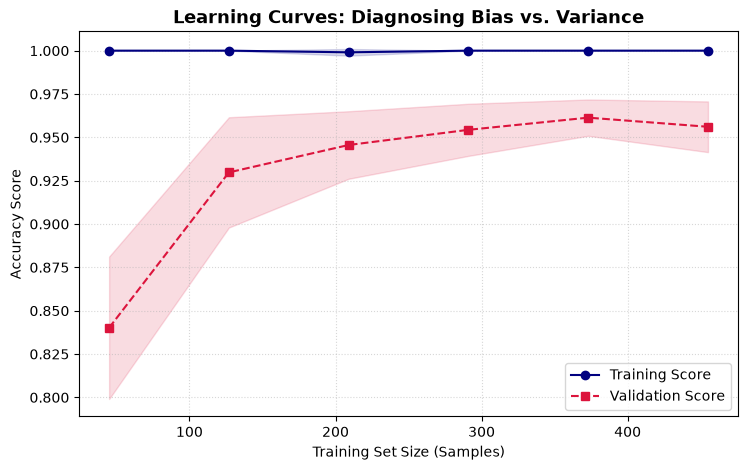

In [4]:
train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_,
    X, y,
    cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(train_sizes, train_mean, 'o-', color='navy', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='navy')

ax.plot(train_sizes, val_mean, 's--', color='crimson', label='Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='crimson')

ax.set_title("Learning Curves: Diagnosing Bias vs. Variance", fontsize=13, fontweight='bold')
ax.set_xlabel("Training Set Size (Samples)")
ax.set_ylabel("Accuracy Score")
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

---
### 4. Model Persistence and Serialization: `joblib`

Deploying a model into production requires saving the fitted pipeline to disk and loading it inside an API:

In [5]:
# Save the optimal tuned pipeline
model_filename = "cancer_detector_v1.joblib"
joblib.dump(grid_search.best_estimator_, model_filename)
print(f"Model serialized successfully to {model_filename}")

# Reload model from disk and verify inference
loaded_model = joblib.load(model_filename)
sample_input = X[:2]
prediction = loaded_model.predict(sample_input)
print("Inference from loaded model:", prediction)

# Clean up
if os.path.exists(model_filename):
    os.remove(model_filename)

Model serialized successfully to cancer_detector_v1.joblib
Inference from loaded model: [0 0]


---
### 5. Advanced Complex Usage: Temporal Walk-Forward Validation with `TimeSeriesSplit`

In financial forecasting, demand prediction, or IoT sensor modeling:
- Standard K-Fold splits randomly, training on future days (e.g. Wednesday) to predict the past (e.g. Monday). This introduces catastrophic **lookahead data leakage**.
- **`TimeSeriesSplit` (Walk-Forward Validation)**: Progressively expands the training window, strictly evaluating on unseen future time steps!
- Coupled with **`cross_validate`** evaluating multiple metrics simultaneously.

In [6]:
# Generate realistic sequential time-series trend
n_time_steps = 300
np.random.seed(42)
time_trend = np.linspace(10, 50, n_time_steps)
seasonal = np.sin(np.linspace(0, 20 * np.pi, n_time_steps)) * 8
noise = np.random.normal(0, 2, n_time_steps)
target_ts = time_trend + seasonal + noise

# Features: Lag 1, Lag 2, Lag 3
df_ts = pd.DataFrame({'y': target_ts})
df_ts['lag_1'] = df_ts['y'].shift(1)
df_ts['lag_2'] = df_ts['y'].shift(2)
df_ts['lag_3'] = df_ts['y'].shift(3)
df_ts.dropna(inplace=True)

X_time = df_ts[['lag_1', 'lag_2', 'lag_3']].values
y_time = df_ts['y'].values

# Initialize TimeSeriesSplit with 5 expanding folds
tscv = TimeSeriesSplit(n_splits=5)

from sklearn.linear_model import Ridge
ts_model = Ridge(alpha=1.0)

# Multi-metric cross-validation
cv_metrics = cross_validate(
    ts_model, 
    X_time, 
    y_time, 
    cv=tscv, 
    scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
    return_train_score=True
)

ts_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train_R2': np.round(cv_metrics['train_r2'], 3),
    'Val_R2': np.round(cv_metrics['test_r2'], 3),
    'Val_RMSE': np.round(-cv_metrics['test_neg_root_mean_squared_error'], 2),
    'Val_MAE': np.round(-cv_metrics['test_neg_mean_absolute_error'], 2)
})

print("Temporal Walk-Forward Multi-Metric Cross-Validation:")
print(ts_results)
print(f"\nAverage Walk-Forward R2 Score: {ts_results['Val_R2'].mean():.3f}")

Temporal Walk-Forward Multi-Metric Cross-Validation:
   Fold  Train_R2  Val_R2  Val_RMSE  Val_MAE
0     1     0.791   0.791      2.88     2.34
1     2     0.860   0.716      3.11     2.61
2     3     0.869   0.770      2.72     2.12
3     4     0.915   0.756      3.33     2.66
4     5     0.935   0.728      3.29     2.58

Average Walk-Forward R2 Score: 0.752


### Curriculum Conclusion & Next Horizons!
Congratulations! You have completed the entire 5-module Machine Learning curriculum:
1. **Module 01 (NumPy):** Multi-dimensional arrays, vectorization, strided views, broadcasting, numerical linear algebra, and ML algorithms from scratch.
2. **Module 02 (Pandas):** DataFrames, MultiIndexes, method chaining, safe filtering, subgroup-conditional imputation, and out-of-fold target encoding.
3. **Module 03 (Matplotlib):** Object-Oriented plotting, dual twin axes, hexbin density maps, inset zoom subplots, decision boundaries, and 3D loss topography.
4. **Module 04 (Seaborn):** Continuous density estimations, faceted conditioning grids, masked correlation heatmaps, hierarchical clustermaps, and automated EDA pipelines.
5. **Module 05 (Scikit-Learn):** Production pipelines, custom transformers, regularized regression, probability calibration, DBSCAN clustering, and temporal walk-forward validation.

You are now fully equipped to tackle real-world machine learning challenges with clean, robust, and production-grade Python code!